In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from astropy.io import fits
# from astropy import stats
# import shutil
from astropy.visualization import simple_norm

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.ndimage import shift
from matplotlib.colors import LogNorm

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from astroquery.ipac.ned import Ned
import astropy.units as u
from astropy.nddata import Cutout2D
from scipy import interpolate
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from IPython.display import clear_output
# from pyBBarolo import *
from scipy import stats

from matplotlib.patches import Rectangle, ConnectionPatch

import warnings
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.utils.data import get_pkg_data_filename


In [4]:
angle_map, ha = fits.getdata("data/output/angle_map.fits", header=True)
distance_map, hd = fits.getdata("data/output/distance_map.fits", header=True)
residS, hs = fits.getdata("data/output/resid_star.fits", header=True)
resid, _ = fits.getdata("data/output/resid_HI.fits", header=True)
resid_mod, _ = fits.getdata("data/output/resid_CO.fits", header=True)
dataHa, hdr = fits.getdata("data/NGC1566_vel_Ha.fits", header=True)
model_vel_map_1_HI = fits.getdata("data/output/model_vel_map_HI.fits")
model_vel_map_mod = fits.getdata("data/output/model_vel_map_mod.fits")

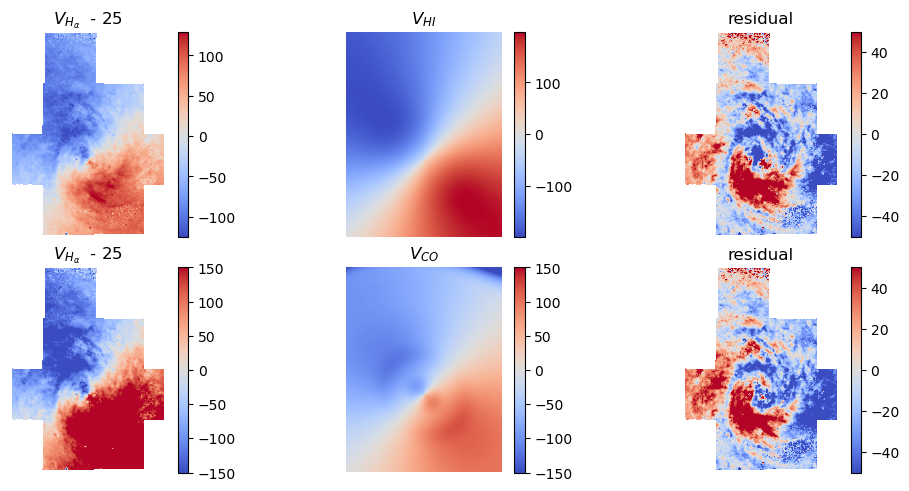

In [8]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, layout="constrained")
# fig.set_figheight(15)
fig.set_figwidth(10)
shift_vel = 25
incl = 32
norm=simple_norm(dataHa - shift_vel, "linear", percent=99.)
im = axs[0, 0].imshow(dataHa- shift_vel, cmap='coolwarm', origin='lower', norm=norm)
fig.colorbar(im, ax=axs[0, 0])
# im.set_clim(vmin=-150, vmax=150)
axs[0, 0].axis("off")
axs[0, 0].set_title(r"$V_{H_{\alpha}}$ "+ f" - {shift_vel}")


norm=simple_norm(model_vel_map_1_HI, "linear", percent=99.)
im = axs[0, 1].imshow(model_vel_map_1_HI, cmap='coolwarm', origin='lower', norm=norm)
# im.set_clim(vmin=-80, vmax=80)
fig.colorbar(im, ax=axs[0, 1])
axs[0, 1].axis("off")
axs[0, 1].set_title(r"$V_{HI}$")

palette = ListedColormap(['#2b3cce','#4c5fdd','#6b80e8','#8ca0f2','#b0c1f9','#d6e1ff','#ffd8ca','#f1b6a1','#e2957b','#d07356','#bd5133','#a82a11'])
resid_HI= (dataHa - shift_vel)/np.sin(np.radians(incl)) - model_vel_map_1_HI
norm = simple_norm(resid_HI, "linear", percent=99)
im = axs[0, 2].imshow(resid_HI, cmap='coolwarm', origin='lower', norm = norm)
# im = axs[0, 2].imshow(resid, cmap=palette, origin='lower', norm = norm)
im.set_clim(vmin=-50, vmax=50)
fig.colorbar(im, ax=axs[0, 2])
axs[0, 2].axis("off")
axs[0, 2].set_title("residual")



norm=simple_norm((dataHa)/np.sin(np.radians(incl)), "linear", percent=99.)
im = axs[1, 0].imshow((dataHa)/np.sin(np.radians(incl)), cmap='coolwarm', origin='lower', norm=norm)
fig.colorbar(im, ax=axs[1, 0])
im.set_clim(vmin=-150, vmax=150)
axs[1, 0].axis("off")
axs[1, 0].set_title(r"$V_{H_{\alpha}}$ "+ f" - {shift_vel}")


norm=simple_norm(model_vel_map_mod*np.sin(np.radians(incl)), "linear", percent=99.)
im = axs[1, 1].imshow(model_vel_map_mod*np.sin(np.radians(incl)) , cmap='coolwarm', origin='lower', norm=norm)
im.set_clim(vmin=-150, vmax=150)
fig.colorbar(im, ax=axs[1, 1])
axs[1, 1].axis("off")
axs[1, 1].set_title(r"$V_{CO}$")

palette = ListedColormap(['#2b3cce','#4c5fdd','#6b80e8','#8ca0f2','#b0c1f9',"#d6d7ff",'#ffd8ca','#f1b6a1','#e2957b','#d07356','#bd5133','#a82a11'])
resid_mod = (dataHa - shift_vel)/np.sin(np.radians(incl)) - model_vel_map_mod
# resid = (dataHa- shift_vel)/np.sin(np.radians(incl)) - model_vel_map_mod
norm = simple_norm(resid_mod, "linear", percent=99)
im = axs[1, 2].imshow(resid_mod, cmap='coolwarm', origin='lower', norm = norm)
# im = axs[1, 2].imshow(resid, cmap=palette, origin='lower', norm = norm)
im.set_clim(vmin=-50, vmax=50)
fig.colorbar(im, ax=axs[1, 2])
axs[1, 2].axis("off")
# axs[1, 2].contour(F_Ha, [1000, 10000, 20000], colors="black")

axs[1, 2].set_title("residual")


plt.show()